In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ticker='AAPL'

In [3]:
data=yf.download(
    ticker,
    start='2020-01-01',
    auto_adjust=True,
    progress=False
)['Close']

In [4]:
data.head()

Ticker,AAPL
Date,
2020-01-02,72.333878
2020-01-03,71.630646
2020-01-06,72.201401
2020-01-07,71.861832
2020-01-08,73.017838


In [5]:
ma20=data.rolling(20).mean()
ma60=data.rolling(60).mean()

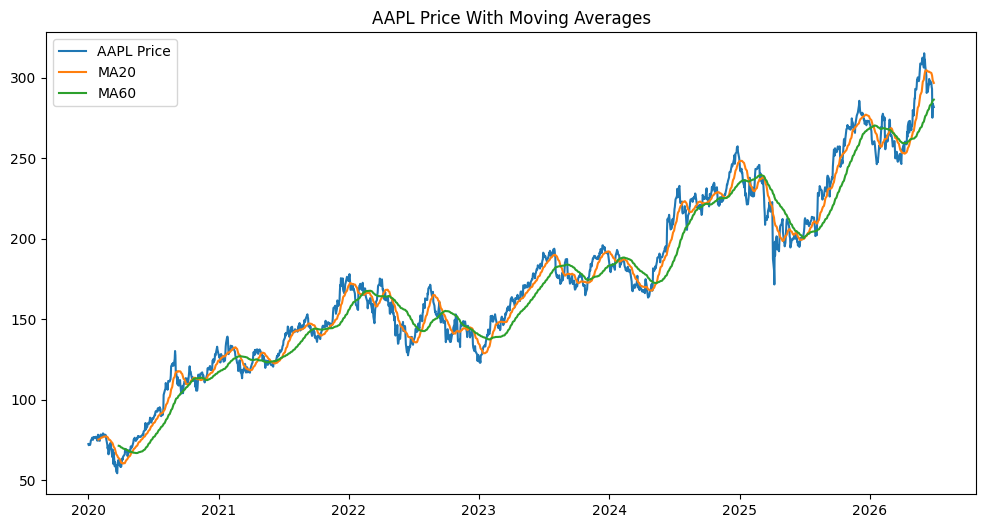

In [6]:
plt.figure(figsize=(12,6))
plt.plot(data,label='AAPL Price')
plt.plot(ma20,label='MA20')
plt.plot(ma60,label='MA60')
plt.title("AAPL Price With Moving Averages")
plt.legend()
plt.show()

In [7]:
signal=ma20>ma60
print(signal.tail())

Ticker      AAPL
Date            
2026-06-23  True
2026-06-24  True
2026-06-25  True
2026-06-26  True
2026-06-29  True


In [8]:
position=signal.astype(int)
print(position.tail())

Ticker      AAPL
Date            
2026-06-23     1
2026-06-24     1
2026-06-25     1
2026-06-26     1
2026-06-29     1


In [9]:
returns=data.pct_change()
print(returns.head())

Ticker          AAPL
Date                
2020-01-02       NaN
2020-01-03 -0.009722
2020-01-06  0.007968
2020-01-07 -0.004703
2020-01-08  0.016087


In [10]:
strategy_returns=returns*position.shift(1)
print(strategy_returns.head())

Ticker      AAPL
Date            
2020-01-02   NaN
2020-01-03  -0.0
2020-01-06   0.0
2020-01-07  -0.0
2020-01-08   0.0


In [20]:
buy_and_hold=(1+returns).cumprod()
strategy=(1+strategy_returns).cumprod()
print(buy_and_hold)
print(strategy_returns)

Ticker          AAPL
Date                
2020-01-02       NaN
2020-01-03  0.990278
2020-01-06  0.998169
2020-01-07  0.993474
2020-01-08  1.009456
...              ...
2026-06-23  4.068633
2026-06-24  4.051767
2026-06-25  3.803888
2026-06-26  3.923196
2026-06-29  3.894994

[1630 rows x 1 columns]
Ticker          AAPL
Date                
2020-01-02       NaN
2020-01-03 -0.000000
2020-01-06  0.000000
2020-01-07 -0.000000
2020-01-08  0.000000
...              ...
2026-06-23 -0.009124
2026-06-24 -0.004145
2026-06-25 -0.061178
2026-06-26  0.031365
2026-06-29 -0.007189

[1630 rows x 1 columns]


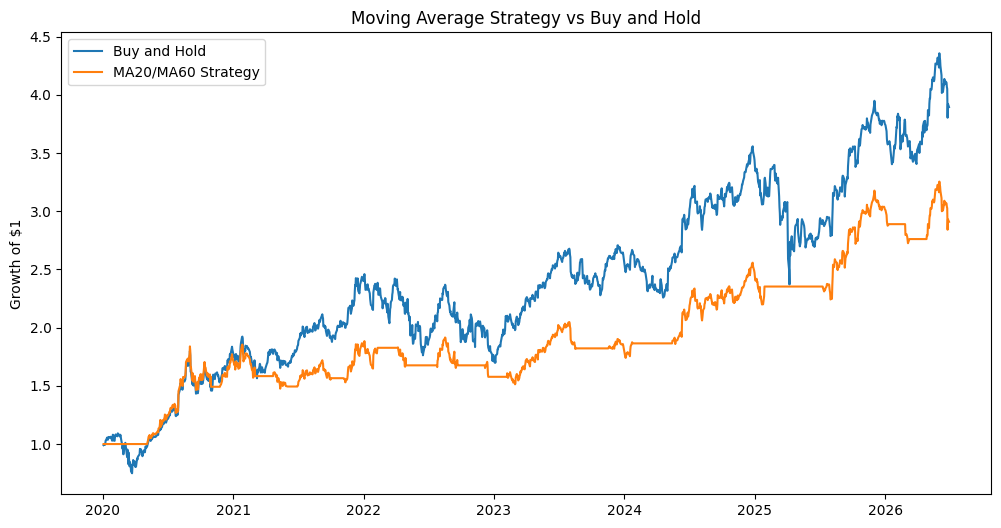

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(buy_and_hold, label="Buy and Hold")
plt.plot(strategy, label="MA20/MA60 Strategy")
plt.title("Moving Average Strategy vs Buy and Hold")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

In [ ]:
final_buy_hold_return=buy_and_hold.iloc[-1]-1
final_strategy=strategy.iloc[-1]-1